---
# STEP 07b TF-IDF 단어 → 별점 회귀분석

## 분석 개요

STEP 06에서는 FPI 지수가 독립 브랜드 별점에 미치는 영향을 검증하였다.
본 분석에서는 **어떤 언어적 특성이 별점을 결정하는가**를 분석한다.
STEP 07에서 구축한 브랜드별 TF-IDF 행렬을 재사용하여
소비자가 어떤 단어를 사용할 때 별점이 높아지고 낮아지는지 직접 파악한다.

| 항목 | 내용 |
|---|---|
| 분석 대상 | 영업 중인 독립 브랜드 3,017개 |
| 입력 데이터 | `tfidf_brand.npz`, `terms_pca.npy`, `brand_texts_meta.csv` (STEP 07 산출물) |
| 독립변수 | TF-IDF 단어 (브랜드 단위, min_df=0.05, max_df=0.90, max_features=500) |
| 종속변수 | 별점 (stars) |
| 전처리 | log(x+1) + StandardScaler |
| 회귀 방법 | OLS + HC3 Robust Standard Error |
| 통제변수 | log(review_count) |

**분석과정**
| 단계 | 내용 |
|---|---|
| STEP 7b-1 | 데이터 로드 (STEP 07 산출물) |
| STEP 7b-2 | 종속변수 매칭 (별점) |
| STEP 7b-3 | 독립변수 전처리 (log(x+1) + StandardScaler) |
| STEP 7b-4 | 다중공선성 확인 (VIF) |
| STEP 7b-5 | OLS + HC3 회귀분석 |
| STEP 7b-6 | 유의미한 단어 추출 및 해석 (p < 0.05) |
| STEP 7b-7 | 시각화 (긍정/부정 바차트) |

**STEP 06, 07, 08과의 관계**
- STEP 06: FPI → 별점 (외부 경쟁 환경의 영향)
- STEP 07b: 리뷰 언어 → 별점 (소비자 언어 특성의 영향) ← 본 분석
- STEP 08: HP 구간 생존/고전 브랜드 언어 패턴 비교 (처방적 전략 도출)
- 07b와 08은 서로 보완적이며, 07b의 유의미 단어가 08 교차 검증에 활용된다.

**종속변수를 별점(stars)으로 한정한 이유**

1. **STEP 06 결과**: 통제변수 투입 후 FPI는 별점에만 유의미한 영향을 미쳤으며(p=0.033),
   감성점수에는 유의미한 영향을 미치지 않는 것으로 나타났다(p=0.384).
   이는 소비자의 리뷰 감성이 주변 프랜차이즈 경쟁 압력보다 다른 요인에 의해
   결정될 가능성을 시사하나, 본 분석에서 그 요인을 특정하기는 어렵다.
   감성점수를 추가 분석할 실익이 낮다고 판단하였다.

2. **순환 관계 문제**: TF-IDF 단어(독립변수)와 감성점수(종속변수)가 모두
   동일한 리뷰 텍스트에서 파생된 변수이므로, 텍스트로 텍스트를 예측하는
   순환 관계가 발생한다. 외부 변수인 별점을 종속변수로 사용하는 것이 타당하다.

## 공통 라이브러리 및 설정

In [7]:
import pandas as pd
import numpy as np
import scipy.sparse as sp
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

fm._load_fontmanager(try_read_cache=False)
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

PATH_to_data = "../results"
PATH_to_save = "../results"

print("라이브러리 로드 완료")

라이브러리 로드 완료


---
## 7b-1. 데이터 로드

STEP 7에서 저장한 브랜드별 TF-IDF 행렬과 메타 정보를 불러온다.

In [8]:
# TF-IDF 행렬 로드
tfidf_brand = sp.load_npz(f"{PATH_to_data}/tfidf_brand.npz")
terms_pca   = np.load(f"{PATH_to_data}/terms_pca.npy", allow_pickle=True)
brand_meta  = pd.read_csv(f"{PATH_to_data}/brand_texts_meta.csv")

# 독립 브랜드 정보 로드
indie_groups = pd.read_csv(f"{PATH_to_data}/biz_indie_with_groups.csv")
indie_groups = indie_groups[indie_groups['is_open'] == 1].copy()

print(f"TF-IDF 행렬: {tfidf_brand.shape}")
print(f"단어 수: {len(terms_pca):,}개")
print(f"브랜드 수: {len(brand_meta):,}개")

TF-IDF 행렬: (3017, 500)
단어 수: 500개
브랜드 수: 3,017개


---
## 7b-2. 종속변수 매칭

브랜드별 TF-IDF 행렬에 별점(stars)을 매칭한다.

In [9]:
# brand_meta에 별점, 리뷰수 매칭
brand_df = brand_meta.merge(
    indie_groups[['business_id', 'stars', 'review_count']],
    on='business_id', how='inner'
)

print(f"매칭 후 브랜드 수: {len(brand_df):,}개")
print(f"별점 분포:\n{brand_df['stars'].describe().round(2)}")

# TF-IDF 행렬도 동일 인덱스로 맞추기
# brand_meta 순서 기준으로 매칭된 인덱스 추출
matched_idx = brand_meta[brand_meta['business_id'].isin(brand_df['business_id'])].index
tfidf_matched = tfidf_brand[matched_idx]

print(f"\nTF-IDF 행렬 최종: {tfidf_matched.shape}")

매칭 후 브랜드 수: 3,017개
별점 분포:
count    3017.00
mean        3.68
std         0.71
min         1.00
25%         3.50
50%         4.00
75%         4.00
max         5.00
Name: stars, dtype: float64

TF-IDF 행렬 최종: (3017, 500)


---
## 7b-3. 독립변수 전처리

TF-IDF 단어 빈도 데이터는 대부분의 값이 0이거나 작고
일부 단어가 극단적으로 높은 값을 가지는 우편향 분포를 보인다.

- **log(x+1) 변환**: 분포 왜도 완화, 고빈도 단어 과도한 영향력 억제
- **StandardScaler**: 단어 간 스케일 표준화 → 계수 크기 비교 가능

In [10]:
# log(x+1) 변환
X_log = tfidf_matched.toarray()
X_log = np.log1p(X_log)

# StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# 통제변수 추가: log(review_count)
log_review = np.log(brand_df['review_count'].values + 1).reshape(-1, 1)
X_final = np.hstack([X_scaled, log_review])

# 컬럼명 설정
feature_names = list(terms_pca) + ['log_review']

# DataFrame 변환 + 상수항
X_df = pd.DataFrame(X_final, columns=feature_names)
X_df = sm.add_constant(X_df)

print(f"최종 독립변수: {X_df.shape}")
print(f"  단어 변수: {len(terms_pca)}개 + log_review 1개 + 상수항 1개")

최종 독립변수: (3017, 502)
  단어 변수: 500개 + log_review 1개 + 상수항 1개


---
## 7b-4. 다중공선성 확인 (VIF)

단어 간 공동출현(co-occurrence)으로 인한 다중공선성을 확인한다.
VIF > 10인 단어는 계수 해석 시 주의가 필요하다.

In [12]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# VIF 계산 (상수항 제외, 단어 변수만)
print("VIF 계산 중... (시간 소요)")
vif_data = pd.DataFrame()
vif_data['feature'] = feature_names
vif_data['VIF'] = [
    variance_inflation_factor(X_df.values, i+1)  # +1: 상수항 제외
    for i in range(len(feature_names))
]

vif_high = vif_data[vif_data['VIF'] > 10].sort_values('VIF', ascending=False)
print(f"\nVIF > 10 단어: {len(vif_high)}개")
print(vif_high.to_string(index=False))
print(f"\nVIF 전체 요약:")
print(vif_data['VIF'].describe().round(2))

VIF 계산 중... (시간 소요)

VIF > 10 단어: 0개
Empty DataFrame
Columns: [feature, VIF]
Index: []

VIF 전체 요약:
count    501.00
mean       2.21
std        0.71
min        1.37
25%        1.75
50%        1.95
75%        2.42
max        5.87
Name: VIF, dtype: float64


---
## 7b-5. OLS + HC3 회귀분석

In [11]:
y = brand_df['stars'].values

model = sm.OLS(y, X_df).fit(cov_type='HC3')

print("=" * 60)
print("OLS + HC3 회귀분석 결과")
print("=" * 60)
print(f"R²        : {model.rsquared:.4f}")
print(f"Adj R²    : {model.rsquared_adj:.4f}")
print(f"F-stat    : {model.fvalue:.4f} (p={model.f_pvalue:.4f})")
print(f"관측치 수 : {int(model.nobs):,}개")
print(f"변수 수   : {model.df_model:.0f}개")

OLS + HC3 회귀분석 결과
R²        : 0.8227
Adj R²    : 0.7874
F-stat    : 22.7981 (p=0.0000)
관측치 수 : 3,017개
변수 수   : 501개


단어 3000개 : R²=0.9996인데 Adj R²=0.9208로 차이가 크게 나는 게 남 -> 과적합임

---
## 7b-6. 유의미한 단어 추출 및 해석 (p < 0.05)

In [13]:
# 유의미한 단어 추출
results_df = pd.DataFrame({
    'word': model.params.index,
    'coef': model.params.values,
    'pvalue': model.pvalues.values
})

# 상수항, log_review 제외
results_df = results_df[
    ~results_df['word'].isin(['const', 'log_review'])
].copy()

# p < 0.05 필터
sig = results_df[results_df['pvalue'] < 0.05].copy()
sig_pos = sig[sig['coef'] > 0].sort_values('coef', ascending=False)
sig_neg = sig[sig['coef'] < 0].sort_values('coef')

print(f"유의미한 단어 수: {len(sig)}개 (p<0.05)")
print(f"  긍정 방향: {len(sig_pos)}개")
print(f"  부정 방향: {len(sig_neg)}개")

print(f"\n=== 별점에 긍정적 영향 (상위 20개) ===")
print(sig_pos[['word', 'coef', 'pvalue']].head(20).round(4).to_string(index=False))

print(f"\n=== 별점에 부정적 영향 (상위 20개) ===")
print(sig_neg[['word', 'coef', 'pvalue']].head(20).round(4).to_string(index=False))

유의미한 단어 수: 40개 (p<0.05)
  긍정 방향: 17개
  부정 방향: 23개

=== 별점에 긍정적 영향 (상위 20개) ===
     word   coef  pvalue
   awesom 0.0651  0.0000
     amaz 0.0564  0.0015
   delici 0.0461  0.0122
    thank 0.0445  0.0016
  favorit 0.0423  0.0028
     glad 0.0382  0.0010
  qualiti 0.0350  0.0047
     work 0.0348  0.0227
    excel 0.0346  0.0170
    quick 0.0342  0.0106
    enjoy 0.0339  0.0253
    coupl 0.0329  0.0059
perfectli 0.0326  0.0136
     taco 0.0301  0.0259
   includ 0.0295  0.0063
    worth 0.0285  0.0415
     soon 0.0279  0.0251

=== 별점에 부정적 영향 (상위 20개) ===
   word    coef  pvalue
  worst -0.0611  0.0000
  money -0.0607  0.0001
   rude -0.0590  0.0001
   slow -0.0483  0.0001
horribl -0.0471  0.0006
terribl -0.0444  0.0003
  least -0.0419  0.0022
   noth -0.0398  0.0047
    bad -0.0394  0.0079
  appet -0.0361  0.0379
   pack -0.0346  0.0019
    pay -0.0319  0.0236
 buffet -0.0303  0.0373
   left -0.0300  0.0218
   lack -0.0298  0.0114
  bland -0.0291  0.0232
    fan -0.0290  0.0277
  charg -0

---
## 7b-7. 시각화 (긍정/부정 바차트)

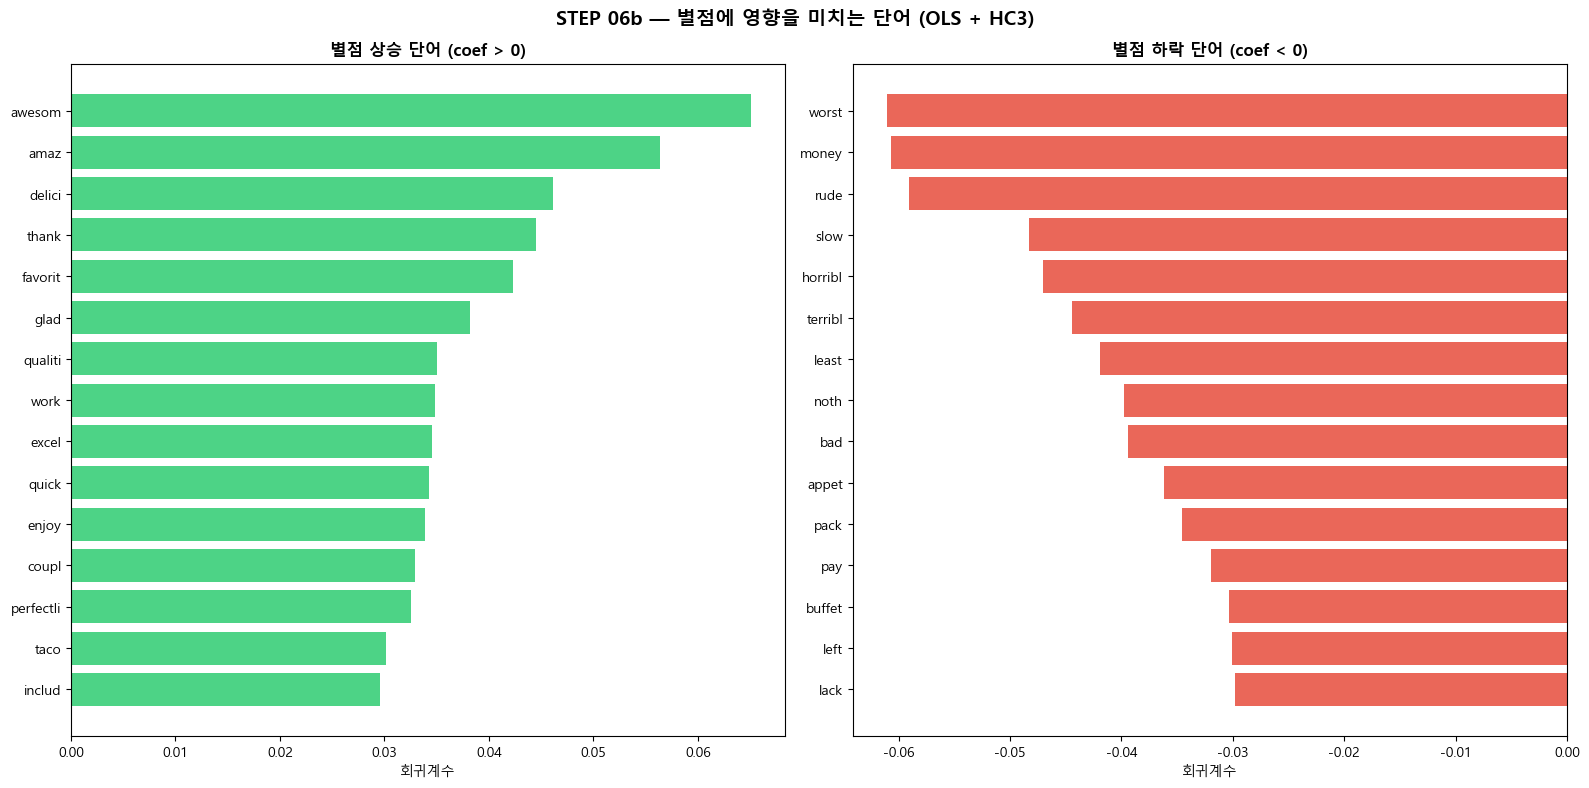

저장 완료: step06b_tfidf_regression.png


In [14]:
# 시각화 — 긍정/부정 상위 15개 바차트
fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('STEP 06b — 별점에 영향을 미치는 단어 (OLS + HC3)',
             fontsize=14, fontweight='bold')

# 긍정
top_pos = sig_pos.head(15)
axes[0].barh(top_pos['word'][::-1], top_pos['coef'][::-1],
             color='#2ecc71', alpha=0.85)
axes[0].set_title('별점 상승 단어 (coef > 0)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('회귀계수')

# 부정
top_neg = sig_neg.head(15)
axes[1].barh(top_neg['word'][::-1], top_neg['coef'][::-1],
             color='#e74c3c', alpha=0.85)
axes[1].set_title('별점 하락 단어 (coef < 0)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('회귀계수')

plt.tight_layout()
plt.savefig(f"{PATH_to_save}/step06b_tfidf_regression.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("저장 완료: step06b_tfidf_regression.png")

---
## STEP 07b 결과 정리

### 모델 성능

| 항목 | 값 |
|---|---|
| R² | 0.8227 |
| Adj R² | 0.7874 |
| F-statistic | 22.80 (p=0.000) |
| 관측치 수 | 3,017개 |
| 변수 수 | 501개 (단어 500개 + log_review) |
| VIF 최대값 | 5.87 (다중공선성 문제 없음) |
| 유의미한 단어 | 40개 (긍정 17개, 부정 23개) |

---

### 별점에 긍정적 영향을 미치는 단어 (coef > 0, p < 0.05)

| 단어 | 원형 | 계수 | 해석 |
|---|---|---|---|
| awesom | awesome | +0.065 | 전반적 감탄 표현 |
| amaz | amazing | +0.056 | 전반적 감탄 표현 |
| delici | delicious | +0.046 | 음식 맛 직접 표현 |
| favorit | favorite | +0.042 | 단골/재방문 의향 |
| excel | excellent | +0.035 | 기대 이상의 경험 |
| qualiti | quality | +0.035 | 품질 직접 언급 |
| perfectli | perfectly | +0.033 | 완벽한 경험 |
| quick | quick | +0.034 | 빠른 서비스 |
| worth | worth | +0.029 | 가성비 만족 |

**해석**: 별점을 높이는 핵심 요인은 **음식 맛(delici) + 전반적 경험 품질(awesom, amaz, excel) + 재방문 의향(favorit)**이다.
메뉴 종류보다 고객의 감정·평가 표현이 별점을 결정한다는 점에서 HW7 Part1 결과와 일치한다.

---

### 별점에 부정적 영향을 미치는 단어 (coef < 0, p < 0.05)

| 단어 | 원형 | 계수 | 해석 |
|---|---|---|---|
| worst | worst | -0.061 | 극단적 부정 표현 |
| money | money | -0.061 | 가격 대비 불만 |
| rude | rude | -0.059 | 직원 불친절 |
| slow | slow | -0.048 | 느린 서비스 |
| horribl | horrible | -0.047 | 극단적 부정 표현 |
| terribl | terrible | -0.044 | 극단적 부정 표현 |
| noth, lack, bland | - | -0.04 내외 | 차별화 없음, 밋밋함 |
| pay, charg | - | -0.03 내외 | 가격/결제 불만 |
| buffet | buffet | -0.030 | 뷔페 부정 경험 |

**해석**: 별점을 낮추는 핵심 요인은 **서비스 불친절(rude) + 느린 서비스(slow) + 가격 불만(money, pay) + 극단적 부정 감정(worst, horribl, terribl)**이다.

---

### STEP 06, STEP 8과의 연계 해석

| 분석 | 핵심 발견 |
|---|---|
| STEP 06 (FPI → 별점) | FPI 높을수록 별점 유의미하게 낮아짐 (coef=-0.012, p=0.033) |
| STEP 07b (단어 → 별점) | 음식 품질·경험 표현이 별점 상승, 서비스 불만·가격 불만이 별점 하락 |
| STEP 8 (생존 브랜드) | 생존 브랜드: delici, amaz, flavor / 고전 브랜드: bad, rude, slow |

세 분석이 일관된 결론을 지지한다.

> **종합 시사점**: 프랜차이즈 경쟁 압력이 높은 환경에서 독립 브랜드가 높은 별점을
> 유지하려면 음식 맛(delici, amaz)과 서비스 품질(rude, slow 회피)에 집중해야 한다.
> 메뉴 종류나 입지보다 **고객이 경험 후 어떤 언어로 표현하는가**가 별점을 결정한다.

---

### 분석 한계

- TF-IDF 단어는 감정 방향(긍정/부정)을 직접 반영하지 않아
  같은 단어라도 맥락에 따라 해석이 달라질 수 있음
- min_df=0.05 필터로 5% 미만 브랜드에서만 나오는 특색 단어가 제외됨
- Restaurants 카테고리 전체 분석으로 업종별 이질성 존재

```현재 07b는 전체 독립 브랜드 대상이라 "일반적으로 맛있으면 별점 높다"는 당연한 결과가 나옴. 반면 HP 구간만 보면 "같은 프랜차이즈 밀집 환경에서도 왜 어떤 브랜드는 살아남고 어떤 브랜드는 고전하는가" 에 직접 답하는 분석이 됨. 프로포절 목적이랑 완전히 일치함. (08분석참고) ```